# Importaciones

In [18]:
import pandas as pd

In [19]:
import spacy
spacy.prefer_gpu()
nlp = spacy.load("es_core_news_md")

In [20]:
from sentence_transformers import SentenceTransformer

___

# Dataset

In [21]:
df = pd.read_csv("./corpus_readability_v1.csv")

In [22]:
df

,Unnamed: 0,texto,doc_id,tiempo_segundos,dificultad
0,0,"El cambio climático es un problema sistémico, ...",0,91.053333,3
1,1,Alumnos de los Talleres Libres de Danza hicier...,1,41.530000,2
2,2,Para conocer las bondades que ofrece la Univer...,2,84.000000,1
3,3,ARTÍCULO 98. Se otorgará mención honorífica cu...,3,37.000000,2
4,4,Artículo 7. La persona titular de la Defensorí...,4,67.253333,2
...,...,...,...,...,...
95,95,Ya circula la Gaceta Unison con información de...,95,45.126667,2
96,96,Este miércoles 8 de marzo da comienzo la tempo...,96,87.000000,2
97,97,ARTÍCULO 46. Los planes de estudio de cada pro...,97,48.000000,1
98,98,Con la participación de 26 alumnas de la Licen...,98,217.300000,4


___

# Limpieza

In [23]:
import re
import unicodedata

def limpiar_texto(texto):
    # Remover letras griegas (alfabeto griego completo)
    # Rango Unicode para letras griegas: U+0370 a U+03FF
    texto = ''.join(char if not ('\u0370' <= char <= '\u03FF') else ' ' for char in texto)

    # Remover símbolos matemáticos y científicos comunes
    texto = re.sub(r'[°±×÷√∞≈≠≤≥]', ' ', texto)

    # Remover guiones bajos
    texto = re.sub(r'_+', ' ', texto)

    # Remover caracteres de control y formato
    texto = ''.join(char for char in texto if unicodedata.category(char)[0] != 'C')

    # Normalizar espacios múltiples a uno solo
    texto = re.sub(r'\s+', ' ', texto)

    return texto

In [24]:
df['texto'] = limpiar_texto(df['texto'].astype(str))

___

## Ajuste de etiquetas

In [25]:
df["dificultad"] = df["dificultad"] - 1

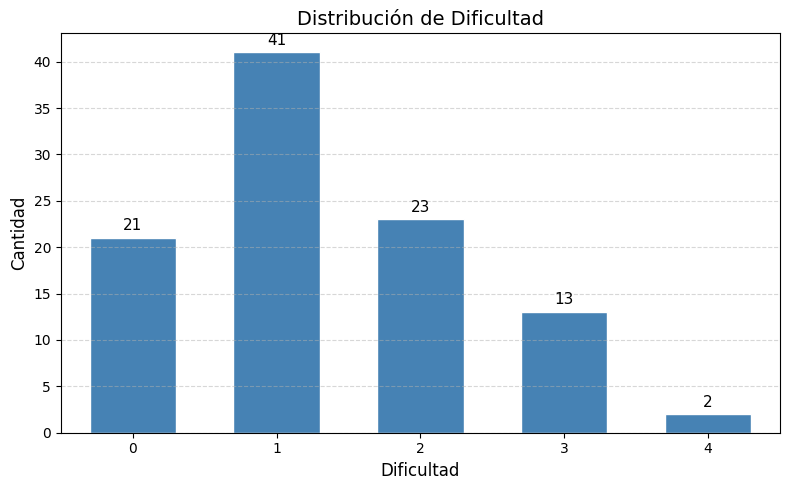

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

counts = df['dificultad'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white', width=0.6)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5,
            str(int(height)), ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Dificultad', fontsize=12)
ax.set_ylabel('Cantidad', fontsize=12)
ax.set_title('Distribución de Dificultad', fontsize=14)
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xlim(-0.5, 4.5)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

___

# División Train/Test

In [27]:
docs = df['texto'].values
y = df['dificultad'].values

In [28]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(docs, y,
                                                            test_size=0.25,
                                                            stratify=y,
                                                            random_state=642)

___

# Generación de embeddings

In [29]:
model_name = "all-mpnet-base-v2"

model = SentenceTransformer(model_name)

embeddings_train = model.encode(X_train_raw, show_progress_bar=True)
embeddings_test = model.encode(X_test_raw, show_progress_bar=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13692.48it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1/1 [00:00<00:00,  1.14it/s]


___

# Clasificación

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

lr = LogisticRegression(max_iter=1000, random_state=642)
lr.fit(embeddings_train, y_train)

y_pred = lr.predict(embeddings_test)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted') 
print(f"\nAccuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")


Accuracy : 0.4000
F1 Score : 0.2286
